# Convolution Tutorial Series — Part 7: ConvTranspose

**Goal:** Understand the `ConvTranspose` operator. While often called "deconvolution", in the context of ARC it is a powerful tool for **shape expansion** and **pattern broadcasting**. We will use ARC Task 127 as an example. The current implementation of task 127 has some additional tricks, similar to what we present in **Part 6:** [Convolution composition](https://www.kaggle.com/code/massimilianoghiotto/convolution-tutorial-series-part-6), but here we present the vanilla version for an easier exposition.

This is the seventh episode of our series:
- **Part 1:** [Kernel Size and Bias](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-1)
- **Part 2:** [Padding](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-2)
- **Part 3:** [Stride](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-3)
- **Part 4:** [Groups](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-4)
- **Part 5:** [Dilations](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-5)
- **Part 6:** [Convolution composition](https://www.kaggle.com/code/massimilianoghiotto/convolution-tutorial-series-part-6)
- **Part 7:** ConvTranspose (this notebook)

---

In [1]:
!pip install -q numpy==2.4.4 2>/dev/null
!pip install -q onnx==1.21.0 2>/dev/null
!pip install -q onnxruntime==1.24.4 2>/dev/null
!pip install -q onnx-tool==1.0.1 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 2.0 MB/s eta 0:00:00


# 1. Task 127

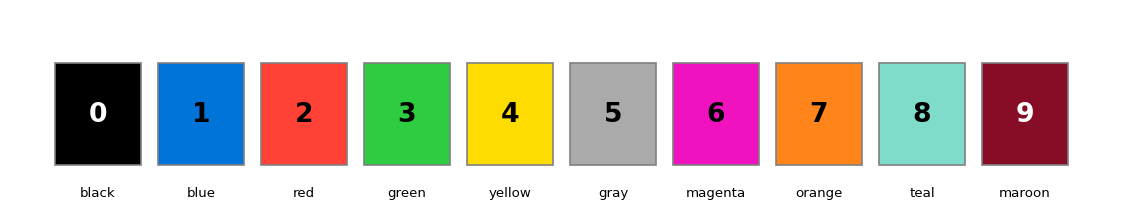

In [2]:
import json, warnings, os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import onnx
from onnx import helper, TensorProto, numpy_helper
import onnxruntime as ort

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

arc_colors = [
    '#000000',  # 0: black
    '#0074D9',  # 1: blue
    '#FF4136',  # 2: red
    '#2ECC40',  # 3: green
    '#FFDC00',  # 4: yellow
    '#AAAAAA',  # 5: gray
    '#F012BE',  # 6: magenta
    '#FF851B',  # 7: orange
    '#7FDBCA',  # 8: teal
    '#870C25',  # 9: maroon
]
color_names = ['black','blue','red','green','yellow','gray','magenta','orange','teal','maroon']

def plot_arc_grid(grid, ax, title=''):
    H, W = len(grid), len(grid[0])
    img = np.zeros((H, W, 3), dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            hex_c = arc_colors[grid[r][c]].lstrip('#')
            img[r,c] = [int(hex_c[i:i+2], 16) for i in (0, 2, 4)]
    ax.imshow(img, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title, fontsize=10, fontweight='bold')
    for r in range(H+1): ax.axhline(r-0.5, color='gray', lw=0.5, alpha=0.3)
    for c in range(W+1): ax.axvline(c-0.5, color='gray', lw=0.5, alpha=0.3)

fig, ax = plt.subplots(figsize=(12, 2))
for i, (c, nm) in enumerate(zip(arc_colors, color_names)):
    ax.add_patch(patches.Rectangle((i*1.2, 0), 1, 1, facecolor=c, edgecolor='gray', lw=1))
    ax.text(i*1.2+0.5, 0.5, str(i), ha='center', va='center', fontsize=16, fontweight='bold',
            color='white' if i in [0,9] else 'black')
    ax.text(i*1.2+0.5, -0.2, nm, ha='center', va='top', fontsize=8)
ax.set_xlim(-0.5, 12.5)
ax.set_ylim(-0.3, 1.5)
ax.axis('off')
plt.show()

In Task 127, we have a grid with gray (5) separator lines. In each region, single colored pixels are present. 

The transformation rule is:
1. Every **Blue (1)** pixel becomes a **3x3 Magenta (6)** block centered on itself.
2. Every **Red (2)** pixel becomes a **3x3 Orange (7)** block centered on itself.
3. Every **Green (3)** pixel becomes a **3x3 Teal (8)** block centered on itself.
4. Every **Yellow (4)** pixel becomes a **3x3 Maroon (9)** block centered on itself.
5. **Gray (5)** lines remain unchanged.

This "one pixel to many pixels" expansion is exactly what `ConvTranspose` does efficiently.

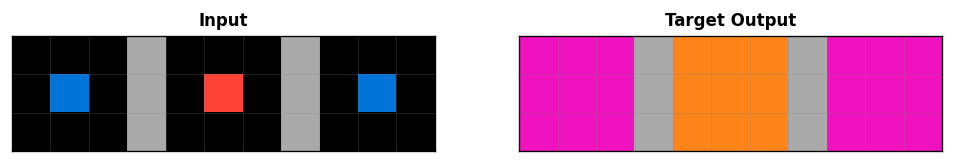

In [3]:
with open('/kaggle/input/competitions/neurogolf-2026/task127.json') as f:
    task = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_arc_grid(task['train'][0]['input'], axes[0], 'Input')
plot_arc_grid(task['train'][0]['output'], axes[1], 'Target Output')
plt.show()

# 2. ConvTranspose

The `ConvTranspose` operator is the "inverse" of `Conv`. While `Conv` usually aggregates information from a neighborhood into a single point, `ConvTranspose` **spreads information from a single point into a neighborhood**.

### Key Concept: The Expansion

Imagine an input with a single `1.0` at some coordinate $(r, c)$ in channel $C_{in}$. 
If we use a `ConvTranspose` with a $3\times3$ kernel $W$ of size $[C_{in}, C_{out}, 3, 3]$:
- The value at $(r, c)$ will be multiplied by the entire $3\times3$ kernel.
- The result will be placed in the output starting at $(r, c)$ (adjusted by padding).

For Task 127, we want the output grid to have the same size as the input grid, so we use `strides=[1, 1]` and `pads=[1, 1, 1, 1]` with a `kernel_shape=[3, 3]`.

### The ConvTranspose Formula

For each input position $(r_{in}, c_{in})$ in channel $c_{in}$, ConvTranspose "stamps" the kernel $W$ onto the output:

$$\text{Output}[n, c_{out}, r_{out}, c_{out}] = \sum_{c_{in}} \sum_{k_r=0}^{kH-1} \sum_{k_c=0}^{kW-1} \text{Input}[n, c_{in}, r_{in}, c_{in}] \cdot W[c_{in}, c_{out}, k_r, k_c]$$

where the output position is determined by:
- $r_{out} = r_{in} \cdot \text{stride}_h + k_r - \text{pad}_{top}$
- $c_{out} = c_{in} \cdot \text{stride}_w + k_c - \text{pad}_{left}$

In other words, each input pixel at $(r_{in}, c_{in})$ contributes its value times the **entire kernel** to a block of output positions starting at $(r_{in} \cdot \text{stride} - \text{pad}, c_{in} \cdot \text{stride} - \text{pad})$.

**Output size:**
$$H_{out} = \text{stride}_h \cdot (H_{in} - 1) + kH - \text{pad}_{top} - \text{pad}_{bottom}$$
$$W_{out} = \text{stride}_w \cdot (W_{in} - 1) + kW - \text{pad}_{left} - \text{pad}_{right}$$

### Understanding Padding in ConvTranspose

Padding in ConvTranspose behaves **oppositely** to padding in regular Conv:

| Operation | Padding effect |
|---|---|
| Regular Conv | Adds border to input $\rightarrow$ output gets **larger** |
| ConvTranspose | Crops border from output $\rightarrow$ output gets **smaller** |

**Why?** ConvTranspose is the mathematical transpose (adjoint) of convolution. Padding in regular Conv adds rows/columns to the convolution matrix $W$; transposing this matrix ($W^T$) naturally crops the output.

**Visual intuition:** With a $3\times3$ kernel on a $30\times30$ input (stride=1):
- **`pad=0`**: Kernel extends 1 pixel beyond input edges $\rightarrow$ output is $32\times32$.
- **`pad=1`** ("same padding"): Edge extensions are exactly cropped $\rightarrow$ output is $30\times30$.
- **`pad=2`**: More output border is cropped $\rightarrow$ output is $28\times28$.

**"Same padding" formula:** To keep output size equal to input size (with stride=1):
$$\text{pad} = \frac{\text{kernel\_size} - 1}{2}$$

For Task 127: $kH=kW=3$, $\text{stride}=1 \rightarrow \text{pad} = \frac{3-1}{2} = 1$. This is why `pads=[1,1,1,1]` keeps the $30\times30$ output.


### Weight Shape Difference

Note that the weight shape for `ConvTranspose` is slightly different from `Conv` in ONNX:
- `Conv` weights: `[M, C/group, kH, kW]` (where M is out_channels)
- `ConvTranspose` weights: `[C, M/group, kH, kW]` (where C is in_channels)

For Task 127, we map input channel 1 (Blue) to output channel 6 (Magenta). We do this by setting a $3\times3$ block of positive weights in $W[1, 6, :, :].$

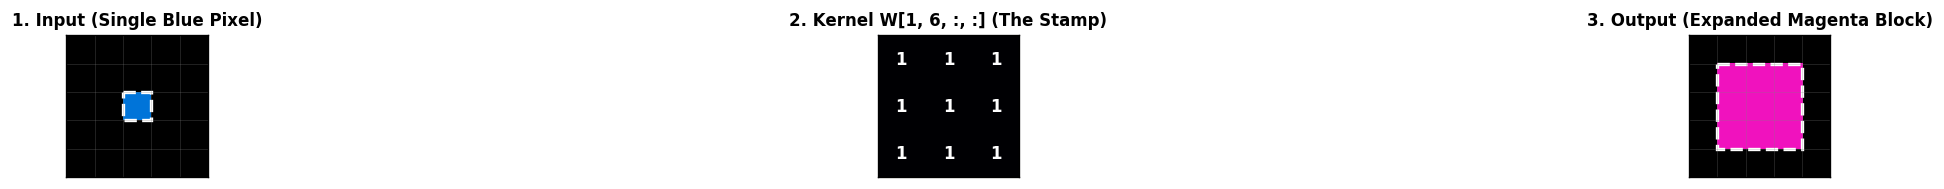

The single Blue pixel at (2,2) acts as a 'trigger'.
ConvTranspose 'stamps' the 3x3 kernel onto the output centered at that trigger.
Since the kernel maps to channel 6, the output becomes a 3x3 Magenta block.


In [4]:
def plot_spread_explanation():
    fig, axes = plt.subplots(1, 3, figsize=(15, 10))
    
    # 1. Input: Single Pixel
    grid_in = np.zeros((5, 5), dtype=int)
    grid_in[2, 2] = 1 # Blue
    plot_arc_grid(grid_in, axes[0], '1. Input (Single Blue Pixel)')
    axes[0].add_patch(patches.Rectangle((1.5, 1.5), 1, 1, fill=False, edgecolor='white', lw=2, ls='--'))

    # 2. Kernel: The "Stamp"
    kernel = np.ones((3, 3))
    axes[1].imshow(kernel, cmap='magma', interpolation='nearest')
    axes[1].set_title('2. Kernel W[1, 6, :, :] (The Stamp)', fontsize=10, fontweight='bold')
    axes[1].set_xticks([]); axes[1].set_yticks([])
    for i in range(3):
        for j in range(3):
            axes[1].text(j, i, '1', ha='center', va='center', color='white', fontweight='bold')
    
    # 3. Output: Expanded Block
    grid_out = np.zeros((5, 5), dtype=int)
    grid_out[1:4, 1:4] = 6 # Magenta
    plot_arc_grid(grid_out, axes[2], '3. Output (Expanded Magenta Block)')
    axes[2].add_patch(patches.Rectangle((0.5, 0.5), 3, 3, fill=False, edgecolor='white', lw=2, ls='--'))

    # Add connecting arrows
    # These are harder to align perfectly across subplots, but we can use figure coordinates
    plt.annotate('', xy=(0.38, 0.5), xycoords='figure fraction', xytext=(0.31, 0.5), 
                 arrowprops=dict(arrowstyle="->", color='black', lw=2))
    plt.annotate('', xy=(0.69, 0.5), xycoords='figure fraction', xytext=(0.62, 0.5), 
                 arrowprops=dict(arrowstyle="->", color='black', lw=2))
    
    plt.tight_layout()
    plt.show()

plot_spread_explanation()
print("The single Blue pixel at (2,2) acts as a 'trigger'.")
print("ConvTranspose 'stamps' the 3x3 kernel onto the output centered at that trigger.")
print("Since the kernel maps to channel 6, the output becomes a 3x3 Magenta block.")

In [5]:
def create_task127_model():
    
    # kernel=3x3  stride=1x1  padding=1,1,1,1  output_padding=0x0  groups=1
    W = np.zeros((10, 10, 3, 3), dtype=np.float32)
    W[1, 6, 0, 0] = 0.01999999955
    W[1, 6, 0, 1] = 0.01999999955
    W[1, 6, 0, 2] = 0.01999999955
    W[1, 6, 1, 0] = 0.01999999955
    W[1, 6, 1, 1] = 0.01999999955
    W[1, 6, 1, 2] = 0.01999999955
    W[1, 6, 2, 0] = 0.01999999955
    W[1, 6, 2, 1] = 0.01999999955
    W[1, 6, 2, 2] = 0.01999999955
    W[2, 7, 0, 0] = 0.01999999955
    W[2, 7, 0, 1] = 0.01999999955
    W[2, 7, 0, 2] = 0.01999999955
    W[2, 7, 1, 0] = 0.01999999955
    W[2, 7, 1, 1] = 0.01999999955
    W[2, 7, 1, 2] = 0.01999999955
    W[2, 7, 2, 0] = 0.01999999955
    W[2, 7, 2, 1] = 0.01999999955
    W[2, 7, 2, 2] = 0.01999999955
    W[3, 8, 0, 0] = 0.01999999955
    W[3, 8, 0, 1] = 0.01999999955
    W[3, 8, 0, 2] = 0.01999999955
    W[3, 8, 1, 0] = 0.01999999955
    W[3, 8, 1, 1] = 0.01999999955
    W[3, 8, 1, 2] = 0.01999999955
    W[3, 8, 2, 0] = 0.01999999955
    W[3, 8, 2, 1] = 0.01999999955
    W[3, 8, 2, 2] = 0.01999999955
    W[4, 9, 0, 0] = 0.01999999955
    W[4, 9, 0, 1] = 0.01999999955
    W[4, 9, 0, 2] = 0.01999999955
    W[4, 9, 1, 0] = 0.01999999955
    W[4, 9, 1, 1] = 0.01999999955
    W[4, 9, 1, 2] = 0.01999999955
    W[4, 9, 2, 0] = 0.01999999955
    W[4, 9, 2, 1] = 0.01999999955
    W[4, 9, 2, 2] = 0.01999999955
    W[5, 5, 1, 1] = 0.01999999955

    # ConvTranspose Node
    node = helper.make_node(
        "ConvTranspose", 
        ["input", "W"], 
        ["output"], 
        kernel_shape=[3, 3], 
        pads=[1, 1, 1, 1], 
        strides=[1, 1],
        group=1,
        output_padding=[0, 0],
    )

    graph = helper.make_graph(
        [node], 
        "task127", 
        inputs=[helper.make_tensor_value_info("input", TensorProto.FLOAT, [1, 10, 30, 30])],
        outputs=[helper.make_tensor_value_info("output", TensorProto.FLOAT, [1, 10, 30, 30])],
        initializer=[numpy_helper.from_array(W, name="W")]
    )

    model = helper.make_model(graph, opset_imports=[helper.make_operatorsetid("", 11)])
    return model

model = create_task127_model()
onnx.save(model, "task127_demo.onnx")

# 3. Running Inference
We convert the input grid to a one-hot tensor, run the model, and then take the `argmax` to get the resulting colors.

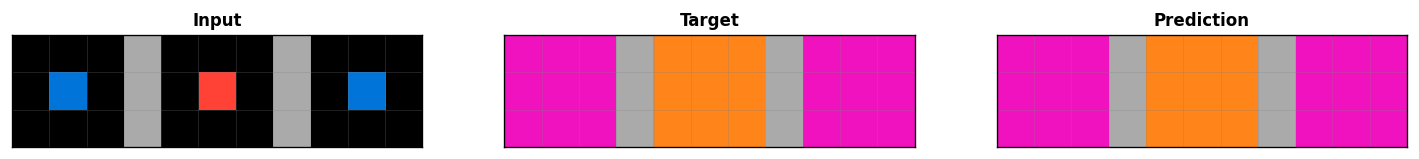

Results on ARC-AGI examples: 5 pass, 0 fail
Results on ARC-GEN examples: 262 pass, 0 fail

Your network IS READY for submission!

Performance stats (memory values reported here are approximate):
Name             Type           Forward_MACs    FPercent    Memory    MPercent      Params  PPercent    InShape     OutShape
---------------  -------------  --------------  ----------  --------  ----------  --------  ----------  ----------  ----------
ConvTranspose_0  ConvTranspose  810,000         100.00%     39,600    100.00%          900  100.00%     1x10x30x30  1x10x30x30
Total            _              810,000         100%        39,600    100%             900  100%        _           _

It appears to require 0 bytes + 900 params, yielding 18.198 points.

Next steps:
 * Click the link below to download task127.onnx onto your local machine.
 * Create a zip file containing that network along with all others.
 * Submit that zip file to the Kaggle competition so that it can be officially score

/kaggle/working/task127.onnx

In [6]:
def run_inference(grid, model_path):
    # Pad input to 30x30 for the model
    oh = np.zeros((1, 10, 30, 30), dtype=np.float32)
    for r in range(len(grid)):
        for c in range(len(grid[0])):
            oh[0, grid[r][c], r, c] = 1.0
            
    sess = ort.InferenceSession(model_path)
    out = sess.run(None, {'input': oh})[0]
    
    # Crop back to original size and get argmax
    res = np.argmax(out[0], axis=0)
    return res[:len(grid), :len(grid[0])]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
inp = task['train'][0]['input']
tgt = task['train'][0]['output']
pred = run_inference(inp, 'task127_demo.onnx')

plot_arc_grid(inp, axes[0], 'Input')
plot_arc_grid(tgt, axes[1], 'Target')
plot_arc_grid(pred, axes[2], 'Prediction')
plt.show()

# Verify with official checker
sys.path.append("/kaggle/input/competitions/neurogolf-2026/neurogolf_utils")
try:
    from neurogolf_utils import verify_network
    passed = verify_network(model, 127, task)
except ImportError:
    print("neurogolf_utils not found. This is expected if running outside the competition environment.")

# Summary
- **Shape Expansion:** `ConvTranspose` is perfect for cases where a single pixel needs to "grow" into a larger shape or pattern.
- **Mapping:** By designing the weights $[C_{in}, C_{out}, kH, kW]$, we can control which input color triggers which output pattern.
- **Identity Maintenance:** Using a $1\times1$ sub-kernel (e.g., at `[1, 1]` for a $3\times3$ kernel) with identity mapping ($C_{in} = C_{out}$) allows preserving specific structures like grid lines.
- **Efficiency:** This approach uses very few parameters (only 100 in this case) and 0 memory if named correctly in the competition setup.

In [7]:
import zipfile

OUTPUT_ZIP = 'submission.zip'
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('task127_demo.onnx', 'task127.onnx')

print(f"Created {OUTPUT_ZIP} with task127.onnx")

Created submission.zip with task127.onnx


In [8]:
import shutil
import os
import zipfile

# --- CONFIGURATION ---
SOURCE_FOLDER = '/kaggle/input/datasets/massimilianoghiotto/neurogolf2026-7243'
OUTPUT_ZIP = '/kaggle/working/submission.zip'

# Package the ZIP (Ensuring files are at the root)
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SOURCE_FOLDER):
        for file in files:
            if file.endswith('.onnx'):
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, SOURCE_FOLDER))



# Acknowledgments
Big shoutout to everyone who shared ideas and notebooks 
@cdeotte, @franksunp, @kojimar, @konbu17, @mirzayasirabdullah07, @nadeembinshajahan, @octaviograu, @qinghchen, @rauffauzanrambe, @sajayr, @seddiktrk, @yash9439 and many more that I might have missed.

### **This is the best that we are able to do for the moment, if anyone has any suggestion, please write it in the comments, we are happy to have some brainstorming between people.**